In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('loan_data.csv')
print(df.shape)
df.head()

(614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [2]:
# For Checking data types and null values
print(df.info())
print("\n--- NULL VALUES ---")
print(df.isnull().sum())
print("\n--- LOAN STATUS DISTRIBUTION ---")
print(df['Loan_Status'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB
None

--- NULL VALUES ---
Loan_ID               0
Gender               13
Married               3
Dependents    

In [4]:
# Filling the missing categorical values with mode
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Married'] = df['Married'].fillna(df['Married'].mode()[0])
df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])

# Filling the missing numerical value with median
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())

# Verifying no nulls remain
print("Null values after cleaning:")
print(df.isnull().sum())

Null values after cleaning:
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


In [5]:
# Create Total Income column (applicant + coapplicant)
df['Total_Income'] = df['ApplicantIncome'] + df['CoapplicantIncome']

# Create income groups
df['Income_Group'] = pd.cut(df['Total_Income'], 
                             bins=[0, 5000, 10000, 25000, 100000],
                             labels=['Low', 'Medium', 'High', 'Very High'])

# Convert Loan_Status to binary (Y=1, N=0)
df['Loan_Approved'] = df['Loan_Status'].map({'Y': 1, 'N': 0})

print("New columns added:")
print(df[['Total_Income', 'Income_Group', 'Loan_Approved']].head(10))

New columns added:
   Total_Income Income_Group  Loan_Approved
0        5849.0       Medium              1
1        6091.0       Medium              0
2        3000.0          Low              1
3        4941.0          Low              1
4        6000.0       Medium              1
5        9613.0       Medium              1
6        3849.0          Low              1
7        5540.0       Medium              0
8        5532.0       Medium              1
9       23809.0         High              0


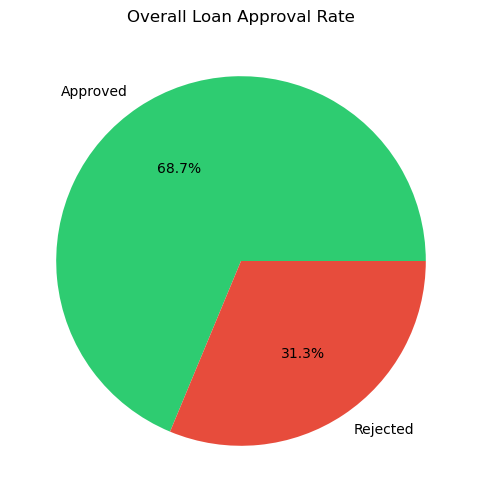

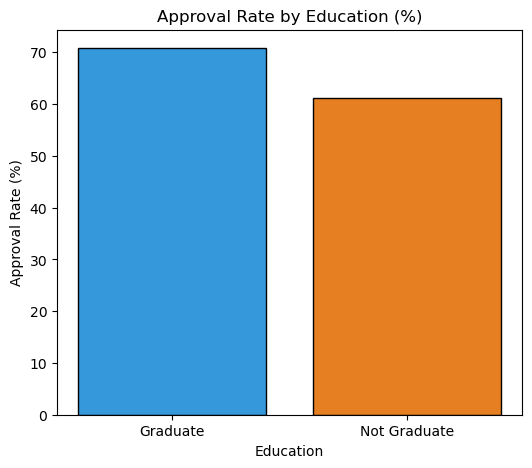

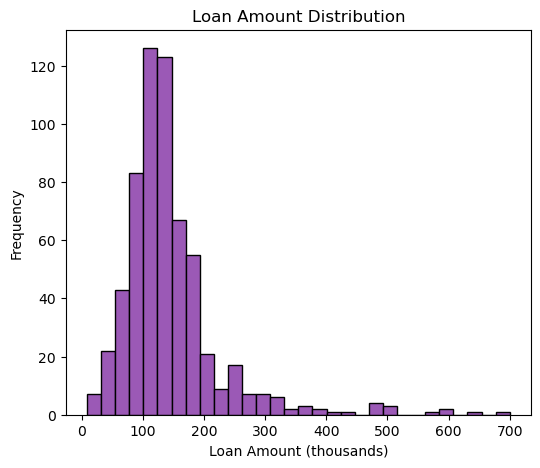

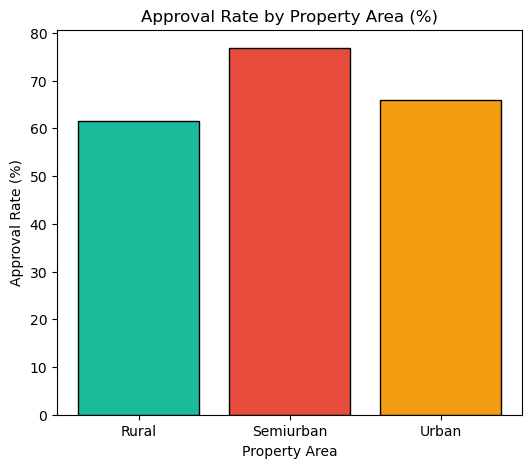

All 4 charts saved!


In [6]:
# Chart 1 - Overall Loan Approval Rate
plt.figure(figsize=(6,6))
loan_counts = df['Loan_Status'].value_counts()
plt.pie(loan_counts, labels=['Approved', 'Rejected'],
        autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'])
plt.title('Overall Loan Approval Rate')
plt.savefig('chart1_approval_rate.png', dpi=150, bbox_inches='tight')
plt.show()

# Chart 2 - Approval Rate by Education
plt.figure(figsize=(6,5))
edu_approval = df.groupby('Education')['Loan_Approved'].mean() * 100
plt.bar(edu_approval.index, edu_approval.values,
        color=['#3498db', '#e67e22'], edgecolor='black')
plt.title('Approval Rate by Education (%)')
plt.xlabel('Education')
plt.ylabel('Approval Rate (%)')
plt.savefig('chart2_education.png', dpi=150, bbox_inches='tight')
plt.show()

# Chart 3 - Loan Amount Distribution
plt.figure(figsize=(6,5))
plt.hist(df['LoanAmount'], bins=30, color='#9b59b6', edgecolor='black')
plt.title('Loan Amount Distribution')
plt.xlabel('Loan Amount (thousands)')
plt.ylabel('Frequency')
plt.savefig('chart3_loan_amount.png', dpi=150, bbox_inches='tight')
plt.show()

# Chart 4 - Approval Rate by Property Area
plt.figure(figsize=(6,5))
area_approval = df.groupby('Property_Area')['Loan_Approved'].mean() * 100
plt.bar(area_approval.index, area_approval.values,
        color=['#1abc9c', '#e74c3c', '#f39c12'], edgecolor='black')
plt.title('Approval Rate by Property Area (%)')
plt.xlabel('Property Area')
plt.ylabel('Approval Rate (%)')
plt.savefig('chart4_property_area.png', dpi=150, bbox_inches='tight')
plt.show()

print("All 4 charts saved!")

In [10]:
pip install pymysql

Note: you may need to restart the kernel to use updated packages.


In [11]:
# Connect to MySQL and load cleaned data
from sqlalchemy import create_engine

username = "root"
password = "your_" 
host = "localhost"
port = "3306"
database = "loan_analysis"  

engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}")

# Load cleaned dataframe into MySQL
df.to_sql('loan_data', engine, if_exists='replace', index=False)
print("Data successfully loaded into MySQL!")

Data successfully loaded into MySQL!


In [12]:
# Export cleaned data to CSV for Power BI
df.to_csv('loan_data_clean.csv', index=False)
print("CSV exported successfully!")

CSV exported successfully!
